In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [2]:
# ==========================================
# 1. DATA LOADING & 1/4 SUBSAMPLING
# ==========================================
df_full = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Use 1/4 (25%) of the data
df = df_full.sample(frac=0.25, random_state=99).reset_index(drop=True)
print(f"Dataset Sampled to 1/4: {df.shape}")

Dataset Sampled to 1/4: (135477, 8)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,574856,22649,STRAWBERRY FAIRY CAKE TEAPOT,1,11/7/2011 12:06,10.79,NaN,United Kingdom
1,581219,10135,COLOURING PENCILS BROWN TUBE,1,12/8/2011 9:28,2.46,NaN,United Kingdom
2,561485,47566,PARTY BUNTING,2,7/27/2011 13:42,4.95,17841.0,United Kingdom
3,571508,23085,ANTIQUE SILVER BAUBLE LAMP,1,10/17/2011 15:27,20.79,NaN,United Kingdom
4,541262,21464,DISCO BALL ROTATOR BATTERY OPERATED,1,1/16/2011 15:50,4.25,18069.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
135472,560285,22348,TEA BAG PLATE RED RETROSPOT,12,7/18/2011 9:21,0.85,14944.0,United Kingdom
135473,539112,21643,ASSORTED TUTTI FRUTTI MIRROR,12,12/16/2010 11:15,1.25,13468.0,United Kingdom
135474,567821,23067,HANGING ENGRAVED METAL HEART,4,9/22/2011 12:45,4.15,14659.0,United Kingdom
135475,545856,22175,PINK OWL SOFT TOY,6,3/7/2011 13:54,2.95,16225.0,United Kingdom
135476,580612,23172,REGENCY TEA PLATE PINK,2,12/5/2011 11:58,3.29,NaN,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135477 entries, 0 to 135476
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    135477 non-null  object 
 1   StockCode    135477 non-null  object 
 2   Description  135105 non-null  object 
 3   Quantity     135477 non-null  int64  
 4   InvoiceDate  135477 non-null  object 
 5   UnitPrice    135477 non-null  float64
 6   CustomerID   101350 non-null  float64
 7   Country      135477 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.3+ MB


In [7]:
df_eda = df.copy()
df_eda['InvoiceDate'] = pd.to_datetime(df_eda['InvoiceDate'])
df_eda['Revenue'] = df_eda['Quantity'] * df_eda['UnitPrice']
df_eda['Month'] = df_eda['InvoiceDate'].dt.month
df_eda['Hour'] = df_eda['InvoiceDate'].dt.hour
df_eda['Day'] = df_eda['InvoiceDate'].dt.day_name()
df_eda['IsCancelled'] = df_eda['InvoiceNo'].str.startswith('C').fillna(False)

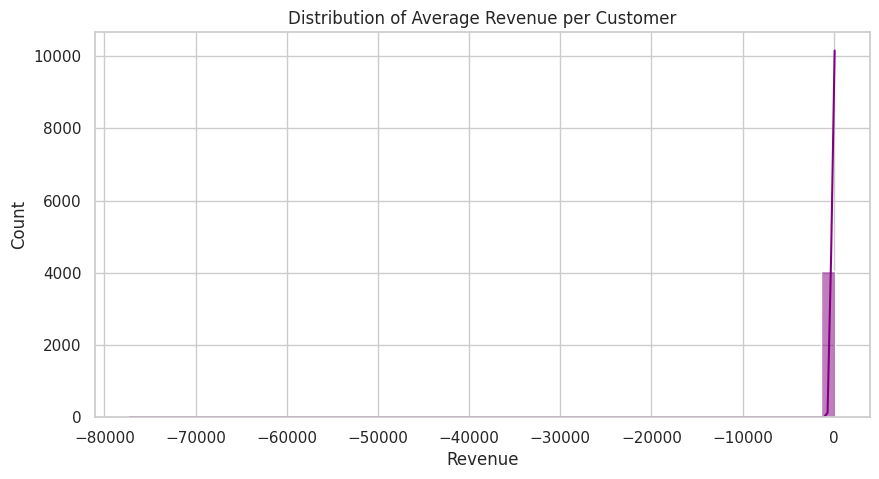

In [8]:
plt.figure(figsize=(10, 5))
cust_rev = df_eda.groupby('CustomerID')['Revenue'].mean()
sns.histplot(cust_rev[cust_rev < 100], bins=50, color='purple', kde=True)
plt.title('Distribution of Average Revenue per Customer')
plt.show()

<Figure size 1000x500 with 0 Axes>

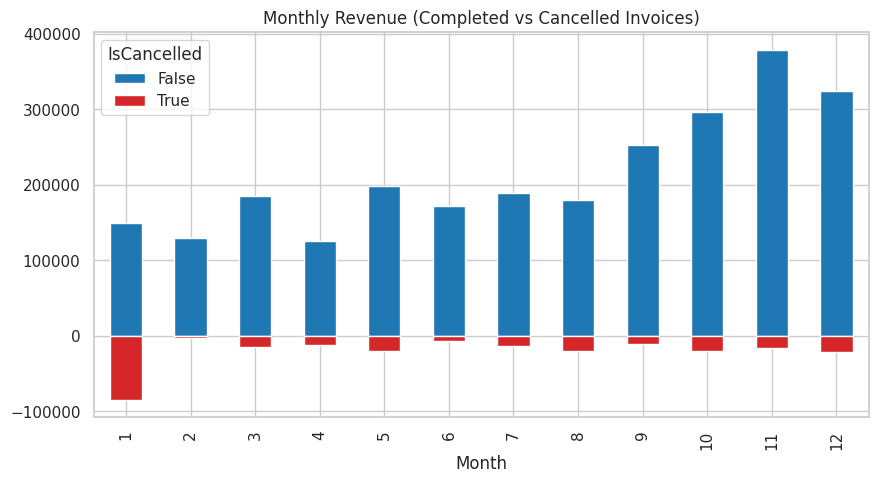

In [9]:
plt.figure(figsize=(10, 5))
month_rev = df_eda.groupby(['Month', 'IsCancelled'])['Revenue'].sum().unstack().fillna(0)
month_rev.plot(kind='bar', stacked=True, color=['#1f77b4', '#d62728'], figsize=(10, 5))
plt.title('Monthly Revenue (Completed vs Cancelled Invoices)')
plt.show()

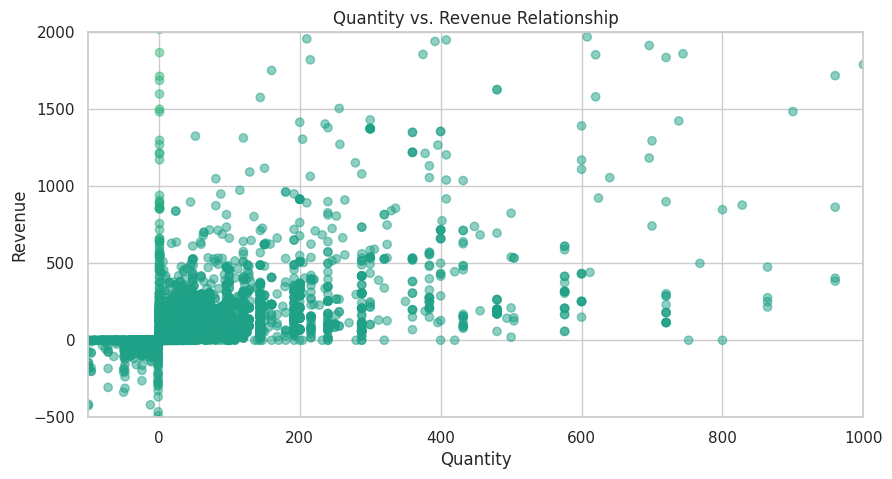

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(df_eda['Quantity'], df_eda['Revenue'], alpha=0.5, c=df_eda['UnitPrice'], cmap='viridis')
plt.title('Quantity vs. Revenue Relationship')
plt.xlabel('Quantity'); plt.ylabel('Revenue')
plt.xlim(-100, 1000); plt.ylim(-500, 2000)
plt.show()

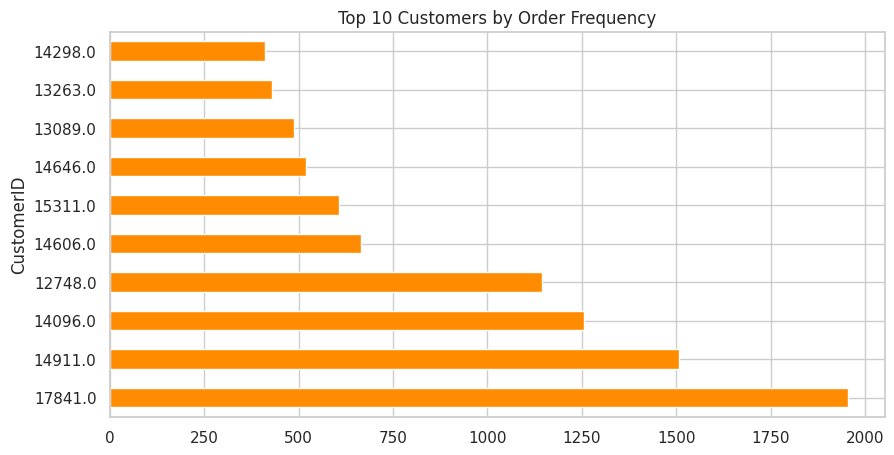

In [12]:
plt.figure(figsize=(10, 5))
df_eda['CustomerID'].value_counts().head(10).plot(kind='barh', color='darkorange')
plt.title('Top 10 Customers by Order Frequency')
plt.show()

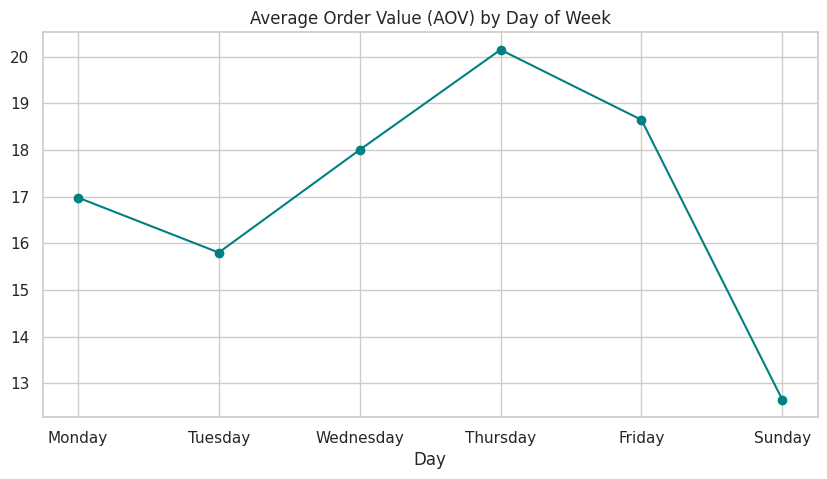

In [13]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Day')['Revenue'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']).plot(kind='line', marker='o', color='teal')
plt.title('Average Order Value (AOV) by Day of Week')
plt.show()

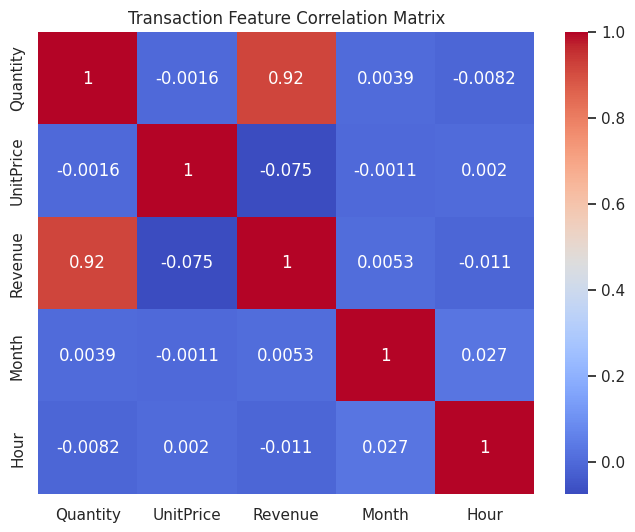

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda[['Quantity', 'UnitPrice', 'Revenue', 'Month', 'Hour']].corr(), annot=True, cmap='coolwarm')
plt.title('Transaction Feature Correlation Matrix')
plt.show()

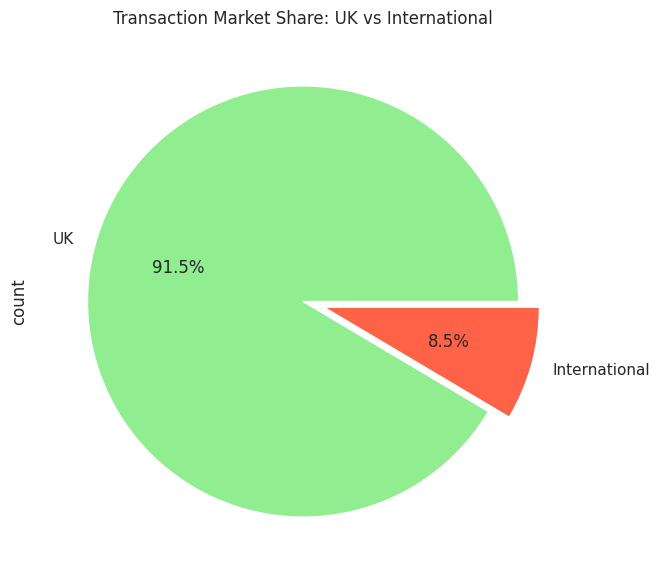

In [15]:
plt.figure(figsize=(7, 7))
df_eda['Region'] = df_eda['Country'].apply(lambda x: 'UK' if x == 'United Kingdom' else 'International')
df_eda['Region'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'tomato'], explode=(0, 0.1))
plt.title('Transaction Market Share: UK vs International')
plt.show()

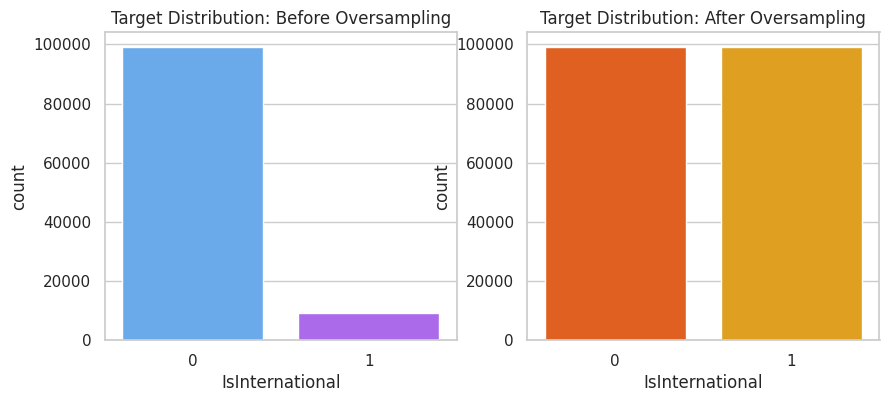

In [16]:
# ==========================================
# 3. PREPROCESSING & RANDOM OVER SAMPLING
# ==========================================
# Target: Is it International?
df['IsInternational'] = (df['Country'] != 'United Kingdom').astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month'] = df['InvoiceDate'].dt.month

X = df[['Quantity', 'UnitPrice', 'Hour', 'Month']].fillna(0)
y = df['IsInternational']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# --- MANUAL RANDOM OVER SAMPLING ---
train_data = pd.concat([X_train, y_train], axis=1)
majority = train_data[train_data['IsInternational'] == 0]
minority = train_data[train_data['IsInternational'] == 1]

# Sample minority with replacement to match majority size
minority_upsampled = minority.sample(len(majority), replace=True, random_state=99)
balanced_df = pd.concat([majority, minority_upsampled]).sample(frac=1)

X_train_res = balanced_df.drop('IsInternational', axis=1)
y_train_res = balanced_df['IsInternational']

# Before/After Visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='cool')
plt.title('Target Distribution: Before Oversampling')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res, palette='autumn')
plt.title('Target Distribution: After Oversampling')
plt.show()

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [17]:
# ==========================================
# 4. 3 ML MODELS & RANKING
# ==========================================
models = {
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=99),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=99),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

In [18]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n---PERFORMANCE RESULTS ---")
print(results_df)


---PERFORMANCE RESULTS ---
               Model  Accuracy  Precision    Recall  F1-Score
1                KNN  0.759116   0.199061  0.609055  0.300054
2           AdaBoost  0.622195   0.157759  0.796691  0.263366
3  Gradient Boosting  0.601971   0.161293  0.879843  0.272611


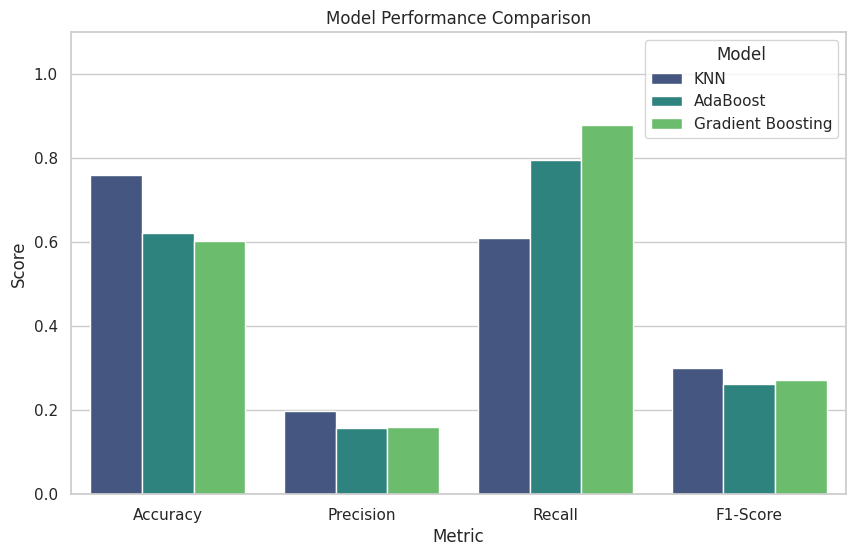

In [19]:
# Final Performance Chart
plt.figure(figsize=(10, 6))
metrics_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melt, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.show()